In [ ]:
import json
import pickle
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print


warnings.filterwarnings("ignore")


# Основні налаштування шляхів до підготовлених даних
DATA_PATH = Path(r"C:\programas\diploma\data\data_processed")
TRAIN_FILE = DATA_PATH / "final_train_clean_top200.csv"
TEST_FILE = DATA_PATH / "final_test_clean_top200.csv"

# Папки для збереження таблиць, графіків і фінальних моделей
OUTPUT_DIR = Path(r"C:\programas\diploma\data\notebooks\model_results")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = Path(r"C:\programas\diploma\data\notebooks\saved_models")

# Назва цільової змінної
TARGET_COL = "TARGET"

# Кількість фолдів для out-of-fold оцінювання
N_SPLITS = 5
RANDOM_STATE = 42


# Функція створює папки для збереження результатів моделювання
def create_output_folders():
    TABLES_DIR.mkdir(parents=True, exist_ok=True)
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(parents=True, exist_ok=True)


# Функція зчитує підготовлені train і test файли
def load_processed_data():
    if not TRAIN_FILE.exists():
        raise FileNotFoundError(f"Файл не знайдено: {TRAIN_FILE}")

    train = pd.read_csv(TRAIN_FILE)

    if TARGET_COL not in train.columns:
        raise ValueError("У train-файлі немає цільової змінної TARGET.")

    if TEST_FILE.exists():
        test = pd.read_csv(TEST_FILE)
    else:
        test = pd.DataFrame()

    y = train[TARGET_COL].astype(int)
    X = train.drop(columns=[TARGET_COL])

    print("Дані завантажено успішно")
    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
    print("\nРозподіл TARGET:")
    print(y.value_counts(normalize=True).rename("share"))

    return X, y, test


# Функція повертає score або ймовірність позитивного класу для моделі
def get_scores_from_estimator(model, X_val):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_val)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_val)

        # Decision function переводиться у діапазон 0..1 для єдиного формату прогнозів
        return 1 / (1 + np.exp(-scores))

    return model.predict(X_val)


# Функція формує classification report без зайвих рядків для підсумкової таблиці
def report_without_accuracy(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    rows = []

    # До таблиці додаються показники для класів і середніх значень
    for label in ["0", "1", "macro avg", "weighted avg"]:
        if label in report:
            rows.append({
                "class/avg": label,
                "precision": report[label]["precision"],
                "recall": report[label]["recall"],
                "f1-score": report[label]["f1-score"],
                "support": report[label]["support"]
            })

    return pd.DataFrame(rows)


# Функція обчислює основні метрики для прогнозних score-значень
def calculate_metrics(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)

    metrics = {
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold
    }

    return metrics, y_pred


# Функція зберігає таблицю у CSV-файл з українським кодуванням
def save_table(table, file_path):
    table.to_csv(file_path, index=False, encoding="utf-8-sig")


# Функція виконує out-of-fold оцінювання звичайних sklearn-моделей
def evaluate_oof_model(name, model, X, y, skf, model_scores, oof_predictions, fitted_models, threshold=0.5):
    oof = np.zeros(len(X), dtype=float)
    models = []

    # На кожному фолді модель навчається на train-частині і прогнозує validation-частину
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        print(f"\n{name} | Fold {fold}: training on {len(tr_idx)} rows, validating on {len(val_idx)} rows")

        model.fit(X_tr, y_tr)

        val_scores = get_scores_from_estimator(model, X_val)
        oof[val_idx] = val_scores
        models.append(model)

        fold_roc = roc_auc_score(y_val, val_scores)
        fold_pr = average_precision_score(y_val, val_scores)

        print(f"Fold {fold}: ROC-AUC={fold_roc:.4f}, PR-AUC={fold_pr:.4f}")

    metrics, y_pred = calculate_metrics(y, oof, threshold)

    print_model_report(name, y, y_pred, metrics)

    model_scores.append({
        "model": name,
        **metrics
    })

    oof_predictions[name] = oof
    fitted_models[name] = models

    return oof, models


# Функція виводить підсумкові метрики, матрицю помилок і classification report
def print_model_report(name, y_true, y_pred, metrics):
    print(f"\n{name} OOF results")
    print(f"ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print(f"PR-AUC : {metrics['PR-AUC']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1-score : {metrics['F1']:.4f}")

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification report без рядка accuracy:")
    display(report_without_accuracy(y_true, y_pred))


# Функція створює логістичну регресію як базову лінійну модель
def build_logistic_regression():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.5,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює Ridge Classifier як додаткову лінійну baseline-модель
def build_ridge_classifier():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier(
            alpha=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює ElasticNet Logistic модель на основі SGDClassifier
def build_elasticnet_logistic():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            alpha=0.0005,
            l1_ratio=0.15,
            class_weight="balanced",
            max_iter=2000,
            tol=1e-4,
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює неглибоку нейронну мережу ANN
def build_ann():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=5e-4,
            batch_size=512,
            learning_rate_init=1e-3,
            max_iter=80,
            early_stopping=True,
            n_iter_no_change=10,
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює глибшу нейронну мережу DNN
def build_dnn():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu",
            solver="adam",
            alpha=2e-4,
            batch_size=512,
            learning_rate_init=8e-4,
            max_iter=80,
            early_stopping=True,
            n_iter_no_change=10,
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює Random Forest для перевірки деревного ансамблю
def build_random_forest():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=20,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює HistGradientBoostingClassifier
def build_hist_gradient_boosting():
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.04,
            max_iter=600,
            max_leaf_nodes=31,
            min_samples_leaf=40,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        ))
    ])

    return model


# Функція створює LightGBM з параметрами, використаними у фінальному експерименті
def build_lightgbm():
    model = lgb.LGBMClassifier(
        n_estimators=40000,
        learning_rate=0.015,
        num_leaves=96,
        min_child_samples=80,
        subsample=0.75,
        subsample_freq=1,
        colsample_bytree=0.75,
        reg_lambda=4.0,
        reg_alpha=1.0,
        objective="binary",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    return model


# Функція створює CatBoost з параметрами, використаними у фінальному експерименті
def build_catboost():
    model = CatBoostClassifier(
        iterations=12000,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=8,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False
    )

    return model


# Функція виконує out-of-fold оцінювання LightGBM з early stopping
def evaluate_lgbm(name, X, y, skf, model_scores, oof_predictions, fitted_models, threshold=0.5):
    oof = np.zeros(len(X), dtype=float)
    models = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = build_lightgbm()

        print(f"\n{name} | Fold {fold}: training on {len(tr_idx)} rows, validating on {len(val_idx)} rows")

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(300, verbose=False)]
        )

        val_scores = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_scores
        models.append(model)

        print(
            f"Fold {fold}: "
            f"ROC-AUC={roc_auc_score(y_val, val_scores):.4f}, "
            f"PR-AUC={average_precision_score(y_val, val_scores):.4f}"
        )

    metrics, y_pred = calculate_metrics(y, oof, threshold)

    print_model_report(name, y, y_pred, metrics)

    model_scores.append({
        "model": name,
        **metrics
    })

    oof_predictions[name] = oof
    fitted_models[name] = models

    return oof, models


# Функція виконує out-of-fold оцінювання CatBoost з early stopping
def evaluate_catboost(name, X, y, skf, model_scores, oof_predictions, fitted_models, threshold=0.5):
    oof = np.zeros(len(X), dtype=float)
    models = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = build_catboost()

        print(f"\n{name} | Fold {fold}: training on {len(tr_idx)} rows, validating on {len(val_idx)} rows")

        model.fit(
            X_tr,
            y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=300,
            verbose=False
        )

        val_scores = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_scores
        models.append(model)

        print(
            f"Fold {fold}: "
            f"ROC-AUC={roc_auc_score(y_val, val_scores):.4f}, "
            f"PR-AUC={average_precision_score(y_val, val_scores):.4f}"
        )

    metrics, y_pred = calculate_metrics(y, oof, threshold)

    print_model_report(name, y, y_pred, metrics)

    model_scores.append({
        "model": name,
        **metrics
    })

    oof_predictions[name] = oof
    fitted_models[name] = models

    return oof, models


# Функція запускає оцінювання лінійних моделей, нейронних мереж і деревних моделей
def evaluate_standard_models(X, y, skf, model_scores, oof_predictions, fitted_models):
    models = [
        ("Logistic Regression", build_logistic_regression()),
        ("Ridge Classifier", build_ridge_classifier()),
        ("ElasticNet Logistic", build_elasticnet_logistic()),
        ("ANN", build_ann()),
        ("DNN", build_dnn()),
        ("Random Forest", build_random_forest()),
        ("HistGradientBoosting", build_hist_gradient_boosting())
    ]

    for name, model in models:
        evaluate_oof_model(
            name=name,
            model=model,
            X=X,
            y=y,
            skf=skf,
            model_scores=model_scores,
            oof_predictions=oof_predictions,
            fitted_models=fitted_models
        )


# Функція підбирає ваги ансамблю LightGBM + CatBoost за ROC-AUC
def find_best_ensemble_weights(y, oof_lgb, oof_cat, step=0.001):
    best_roc = -1
    best_pr = -1
    best_weights = None
    rows = []

    for w_lgb in np.arange(0.0, 1.0 + step, step):
        w_cat = 1 - w_lgb

        oof_ensemble = w_lgb * oof_lgb + w_cat * oof_cat

        roc = roc_auc_score(y, oof_ensemble)
        pr = average_precision_score(y, oof_ensemble)

        rows.append({
            "w_lgb": w_lgb,
            "w_cat": w_cat,
            "ROC-AUC": roc,
            "PR-AUC": pr
        })

        if roc > best_roc:
            best_roc = roc
            best_pr = pr
            best_weights = (w_lgb, w_cat)

    weights_table = pd.DataFrame(rows)

    print("\nНайкращі ваги ансамблю за ROC-AUC:")
    print(f"LightGBM weight: {best_weights[0]:.3f}")
    print(f"CatBoost weight: {best_weights[1]:.3f}")
    print(f"ROC-AUC: {best_roc:.4f}")
    print(f"PR-AUC : {best_pr:.4f}")

    display(weights_table.sort_values("ROC-AUC", ascending=False).head(10))

    return best_weights, weights_table


# Функція додає ансамбль LightGBM + CatBoost до загального списку результатів
def evaluate_ensemble(y, oof_lgb, oof_cat, model_scores, oof_predictions, weights):
    w_lgb, w_cat = weights

    oof_blend = w_lgb * oof_lgb + w_cat * oof_cat
    metrics, y_pred = calculate_metrics(y, oof_blend, threshold=0.5)

    print_model_report("LightGBM + CatBoost Ensemble", y, y_pred, metrics)

    model_scores.append({
        "model": "LightGBM + CatBoost Ensemble",
        **metrics
    })

    oof_predictions["LightGBM + CatBoost Ensemble"] = oof_blend

    return oof_blend


# Функція формує фінальну таблицю порівняння моделей
def build_results_table(model_scores):
    results = (
        pd.DataFrame(model_scores)
        .sort_values(["ROC-AUC", "PR-AUC"], ascending=False)
        .reset_index(drop=True)
    )

    display(results)

    return results


# Функція будує загальний графік ROC-кривих для всіх моделей
def plot_all_roc_curves(y, oof_predictions):
    plt.figure(figsize=(8, 6))

    for name, oof in oof_predictions.items():
        fpr, tpr, _ = roc_curve(y, oof)
        auc_value = roc_auc_score(y, oof)
        plt.plot(fpr, tpr, label=f"{name}: {auc_value:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "roc_curves_all_models.png", dpi=300)
    plt.show()


# Функція будує окремі ROC-криві для кожної моделі
def plot_individual_roc_curves(y, oof_predictions):
    for name, oof in oof_predictions.items():
        fpr, tpr, _ = roc_curve(y, oof)
        auc_value = roc_auc_score(y, oof)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        file_name = f"roc_curve_{name.lower().replace(' ', '_').replace('+', 'plus')}.png"
        plt.savefig(FIGURES_DIR / file_name, dpi=300)
        plt.show()


# Функція будує загальний графік Precision-Recall кривих для всіх моделей
def plot_all_pr_curves(y, oof_predictions):
    plt.figure(figsize=(8, 6))

    for name, oof in oof_predictions.items():
        precision, recall, _ = precision_recall_curve(y, oof)
        pr_value = average_precision_score(y, oof)
        plt.plot(recall, precision, label=f"{name}: {pr_value:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "precision_recall_curves_all_models.png", dpi=300)
    plt.show()


# Функція будує окремі Precision-Recall криві для кожної моделі
def plot_individual_pr_curves(y, oof_predictions):
    for name, oof in oof_predictions.items():
        precision, recall, _ = precision_recall_curve(y, oof)
        pr_value = average_precision_score(y, oof)

        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"PR-AUC = {pr_value:.3f}")

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve — {name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        file_name = f"pr_curve_{name.lower().replace(' ', '_').replace('+', 'plus')}.png"
        plt.savefig(FIGURES_DIR / file_name, dpi=300)
        plt.show()


# Функція підбирає поріг класифікації, який максимізує F1-score
def find_best_threshold_f1(y_true, scores, thresholds=np.arange(0.05, 0.96, 0.01)):
    best_threshold = 0.5
    best_f1 = -1

    for threshold in thresholds:
        prediction = (scores >= threshold).astype(int)
        current_f1 = f1_score(y_true, prediction, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return best_threshold, best_f1


# Функція формує таблицю найкращих порогів для всіх моделей
def build_threshold_results(y, oof_predictions):
    rows = []

    for name, oof in oof_predictions.items():
        best_threshold, best_f1 = find_best_threshold_f1(y, oof)
        prediction = (oof >= best_threshold).astype(int)

        rows.append({
            "model": name,
            "best_threshold_by_F1": best_threshold,
            "precision": precision_score(y, prediction, zero_division=0),
            "recall": recall_score(y, prediction, zero_division=0),
            "F1": best_f1,
            "ROC-AUC": roc_auc_score(y, oof),
            "PR-AUC": average_precision_score(y, oof)
        })

    threshold_results = (
        pd.DataFrame(rows)
        .sort_values(["F1", "PR-AUC"], ascending=False)
        .reset_index(drop=True)
    )

    display(threshold_results)

    return threshold_results


# Функція навчає фінальні LightGBM і CatBoost на всьому train-наборі
def train_final_models(X, y):
    final_lgb = build_lightgbm()
    final_lgb.fit(X, y)

    final_cat = build_catboost()
    final_cat.fit(X, y, verbose=False)

    return final_lgb, final_cat


# Функція зберігає фінальні моделі та ваги ансамблю у файли
def save_final_models(final_lgb, final_cat, lgb_models, cat_models, weights):
    w_lgb, w_cat = weights

    joblib.dump(final_lgb, MODELS_DIR / "lightgbm_model.pkl")

    with open(MODELS_DIR / "lightgbm_models.pkl", "wb") as file:
        pickle.dump(lgb_models, file)

    final_cat.save_model(str(MODELS_DIR / "catboost_model.cbm"))

    with open(MODELS_DIR / "catboost_models.pkl", "wb") as file:
        pickle.dump(cat_models, file)

    weights_dict = {
        "lightgbm": float(w_lgb),
        "catboost": float(w_cat)
    }

    with open(MODELS_DIR / "ensemble_weights.json", "w", encoding="utf-8") as file:
        json.dump(weights_dict, file, indent=4)

    print("\nФінальні файли збережено у папці:")
    print(MODELS_DIR)


# Функція повертає ймовірність дефолту для фінального ансамблю
def predict_ensemble(X_new, final_lgb, final_cat, weights):
    w_lgb, w_cat = weights

    pred_lgb = final_lgb.predict_proba(X_new)[:, 1]
    pred_cat = final_cat.predict_proba(X_new)[:, 1]

    return w_lgb * pred_lgb + w_cat * pred_cat


# Функція запускає весь процес навчання, порівняння та збереження моделей
def main():
    create_output_folders()

    X, y, test = load_processed_data()

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    model_scores = []
    oof_predictions = {}
    fitted_models = {}

    evaluate_standard_models(
        X=X,
        y=y,
        skf=skf,
        model_scores=model_scores,
        oof_predictions=oof_predictions,
        fitted_models=fitted_models
    )

    oof_lgb, lgb_models = evaluate_lgbm(
        name="LightGBM",
        X=X,
        y=y,
        skf=skf,
        model_scores=model_scores,
        oof_predictions=oof_predictions,
        fitted_models=fitted_models
    )

    oof_cat, cat_models = evaluate_catboost(
        name="CatBoost",
        X=X,
        y=y,
        skf=skf,
        model_scores=model_scores,
        oof_predictions=oof_predictions,
        fitted_models=fitted_models
    )

    weights, weights_table = find_best_ensemble_weights(
        y=y,
        oof_lgb=oof_lgb,
        oof_cat=oof_cat,
        step=0.001
    )

    evaluate_ensemble(
        y=y,
        oof_lgb=oof_lgb,
        oof_cat=oof_cat,
        model_scores=model_scores,
        oof_predictions=oof_predictions,
        weights=weights
    )

    results = build_results_table(model_scores)
    save_table(results, TABLES_DIR / "model_comparison_results.csv")
    save_table(weights_table, TABLES_DIR / "ensemble_weight_search.csv")

    plot_all_roc_curves(y, oof_predictions)
    plot_individual_roc_curves(y, oof_predictions)
    plot_all_pr_curves(y, oof_predictions)
    plot_individual_pr_curves(y, oof_predictions)

    threshold_results = build_threshold_results(y, oof_predictions)
    save_table(threshold_results, TABLES_DIR / "best_thresholds_by_f1.csv")

    final_lgb, final_cat = train_final_models(X, y)

    save_final_models(
        final_lgb=final_lgb,
        final_cat=final_cat,
        lgb_models=lgb_models,
        cat_models=cat_models,
        weights=weights
    )

    example_prediction = predict_ensemble(
        X_new=X.iloc[:10],
        final_lgb=final_lgb,
        final_cat=final_cat,
        weights=weights
    )

    print("\nПриклад прогнозів фінального ансамблю:")
    print(example_prediction)

    print("\nПобудову та порівняння моделей завершено.")


# Запуск усіх етапів моделювання
main()


## 0. Завантаження даних

`TARGET` — цільова змінна. Усі інші колонки використовуються як ознаки.

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

DATA_PATH = r"C:\programas\diploma\data\data_processed"

train = pd.read_csv(os.path.join(DATA_PATH, "final_train_clean_top200.csv"))
test  = pd.read_csv(os.path.join(DATA_PATH, "final_test_clean_top200.csv"))

print("Train shape:", train.shape)
print("Test shape:", test.shape)

y = train["TARGET"].astype(int)
X = train.drop(columns=["TARGET"])

print("Target distribution:")
print(y.value_counts(normalize=True).rename("share"))

Train shape: (307511, 202)
Test shape: (48744, 201)
Target distribution:
TARGET
0    0.919271
1    0.080729
Name: share, dtype: float64


## 1. Єдина схема оцінювання

Для всіх моделей використовується однакова схема: **Stratified K-Fold** та out-of-fold прогнозування.

Це означає, що кожен об’єкт отримує прогноз від моделі, яка не бачила його під час навчання. Такий підхід дає чесніше порівняння моделей, ніж оцінювання на тих самих даних, на яких модель навчалася.

Для кожної моделі виводяться:

- ROC-AUC;
- PR-AUC;
- матриця помилок;
- precision, recall, F1-score та support;
- інформація про навчання на кожному фолді.

In [2]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_scores = []
oof_predictions = {}
fitted_models = {}

def get_scores_from_estimator(model, X_val):
    """Повертає score/probability для позитивного класу."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_val)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_val)
        # Переведення decision_function у діапазон 0..1 для єдиного формату порогів.
        return 1 / (1 + np.exp(-scores))
    return model.predict(X_val)

def report_without_accuracy(y_true, y_pred):
    """Classification report без рядка accuracy."""
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    rows = []
    for label in ["0", "1", "macro avg", "weighted avg"]:
        if label in rep:
            rows.append({
                "class/avg": label,
                "precision": rep[label]["precision"],
                "recall": rep[label]["recall"],
                "f1-score": rep[label]["f1-score"],
                "support": rep[label]["support"],
            })
    return pd.DataFrame(rows)

def evaluate_oof_model(name, model, X, y, threshold=0.5):
    """Навчає модель по фолдах, рахує OOF-метрики та друкує звіт."""
    oof = np.zeros(len(X), dtype=float)
    fold_metrics = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        print(f"{name} | Fold {fold}: training on {len(tr_idx)} rows, validating on {len(val_idx)} rows")
        model.fit(X_tr, y_tr)

        val_scores = get_scores_from_estimator(model, X_val)
        oof[val_idx] = val_scores

        fold_roc = roc_auc_score(y_val, val_scores)
        fold_pr = average_precision_score(y_val, val_scores)
        fold_metrics.append((fold_roc, fold_pr))
        print(f"Fold {fold}: ROC-AUC={fold_roc:.4f}, PR-AUC={fold_pr:.4f}")

    y_pred = (oof >= threshold).astype(int)

    roc = roc_auc_score(y, oof)
    pr = average_precision_score(y, oof)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    print("\nOOF results")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC : {pr:.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y, y_pred))
    print("\nClassification report без accuracy:")
    display(report_without_accuracy(y, y_pred))

    model_scores.append({
        "model": name,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "threshold": threshold
    })
    oof_predictions[name] = oof

    return oof

# Частина 1. Лінійні моделі

Лінійні моделі використовуються першими, тому що вони є зрозумілим baseline. Якщо складніші моделі дають лише незначне покращення, це означає, що значна частина сигналу вже описується лінійною залежністю між ознаками та цільовою змінною.

## 1.1 Logistic Regression

Логістична регресія є базовою моделлю для бінарної класифікації.  
Використано L2-регуляризацію, щоб зменшити перенавчання за великої кількості ознак.

Основні гіперпараметри:

- `C=0.5` — помірна регуляризація;
- `solver="liblinear"` — стабільний solver для невеликих/середніх табличних задач;
- `class_weight="balanced"` — компенсація дисбалансу класів;
- `max_iter=2000` — достатня кількість ітерацій для збіжності.

In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.5,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

oof_log_reg = evaluate_oof_model("Logistic Regression", log_reg, X, y)

Logistic Regression | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7640, PR-AUC=0.2491
Logistic Regression | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7752, PR-AUC=0.2612
Logistic Regression | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7710, PR-AUC=0.2489
Logistic Regression | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7735, PR-AUC=0.2570
Logistic Regression | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7675, PR-AUC=0.2434

OOF results
ROC-AUC: 0.7702
PR-AUC : 0.2515

Confusion matrix:
[[199477  83209]
 [  7508  17317]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.963727,0.705649,0.814739,282686.0
1,1,0.172264,0.697563,0.276296,24825.0
2,macro avg,0.567995,0.701606,0.545518,307511.0
3,weighted avg,0.899833,0.704996,0.771271,307511.0


## 1.2 RidgeClassifier

RidgeClassifier — ще одна лінійна модель з L2-регуляризацією.  
Її використано як додатковий baseline, щоб перевірити стабільність лінійного підходу.

Основний гіперпараметр:

- `alpha=1.0` — сила L2-регуляризації.

In [4]:
from sklearn.linear_model import RidgeClassifier

ridge = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeClassifier(
        alpha=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

oof_ridge = evaluate_oof_model("Ridge Classifier", ridge, X, y)

Ridge Classifier | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7640, PR-AUC=0.2503
Ridge Classifier | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7753, PR-AUC=0.2620
Ridge Classifier | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7706, PR-AUC=0.2491
Ridge Classifier | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7734, PR-AUC=0.2574
Ridge Classifier | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7671, PR-AUC=0.2445

OOF results
ROC-AUC: 0.7701
PR-AUC : 0.2522

Confusion matrix:
[[199701  82985]
 [  7536  17289]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.963636,0.706441,0.815234,282686.0
1,1,0.172418,0.696435,0.276405,24825.0
2,macro avg,0.568027,0.701438,0.545820,307511.0
3,weighted avg,0.899762,0.705633,0.771735,307511.0


## 1.3 ElasticNet Logistic Model

Замість звичайного ElasticNet-регресора використано `SGDClassifier` з `loss="log_loss"` і `penalty="elasticnet"`, тобто це саме класифікаційна модель.

ElasticNet поєднує L1 та L2 регуляризацію:

- L1 може зануляти частину менш важливих коефіцієнтів;
- L2 стабілізує оцінки при корельованих ознаках.

Основні гіперпараметри:

- `alpha=0.0005` — сила регуляризації;
- `l1_ratio=0.15` — частка L1-компоненти;
- `class_weight="balanced"` — врахування дисбалансу класів.

In [5]:
from sklearn.linear_model import SGDClassifier

elastic_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SGDClassifier(
        loss="log_loss",
        penalty="elasticnet",
        alpha=0.0005,
        l1_ratio=0.15,
        class_weight="balanced",
        max_iter=2000,
        tol=1e-4,
        random_state=42
    ))
])

oof_elastic = evaluate_oof_model("ElasticNet Logistic", elastic_log, X, y)

ElasticNet Logistic | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7598, PR-AUC=0.2401
ElasticNet Logistic | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7687, PR-AUC=0.2509
ElasticNet Logistic | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7672, PR-AUC=0.2448
ElasticNet Logistic | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7700, PR-AUC=0.2517
ElasticNet Logistic | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7646, PR-AUC=0.2405

OOF results
ROC-AUC: 0.7661
PR-AUC : 0.2452

Confusion matrix:
[[199357  83329]
 [  7633  17192]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.963124,0.705224,0.814240,282686.0
1,1,0.171029,0.692528,0.274313,24825.0
2,macro avg,0.567076,0.698876,0.544277,307511.0
3,weighted avg,0.899179,0.704199,0.770653,307511.0


# Частина 2. Нейронні мережі

Нейронні мережі перевіряються після лінійних моделей. Їхня мета — з’ясувати, чи покращує якість нелінійне перетворення ознак.

Для табличних даних нейронні мережі не завжди кращі за бустинг, тому вони розглядаються як окремий етап експерименту, а не як автоматично найсильніший підхід.

## 2.1 ANN: неглибока нейронна мережа

ANN має одну приховану частину середньої складності.  
Використано ReLU-активацію, Adam-оптимізатор та early stopping.

Основні гіперпараметри:

- `hidden_layer_sizes=(128, 64)` — дві приховані частини;
- `activation="relu"` — стандартна нелінійність для MLP;
- `alpha=0.0005` — L2-регуляризація;
- `learning_rate_init=0.001` — початковий крок навчання;
- `early_stopping=True` — контроль перенавчання.

In [6]:
from sklearn.neural_network import MLPClassifier

ann = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=5e-4,
        batch_size=512,
        learning_rate_init=1e-3,
        max_iter=80,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])

oof_ann = evaluate_oof_model("ANN", ann, X, y)

ANN | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7547, PR-AUC=0.2366
ANN | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7703, PR-AUC=0.2562
ANN | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7648, PR-AUC=0.2448
ANN | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7705, PR-AUC=0.2559
ANN | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7665, PR-AUC=0.2462

OOF results
ROC-AUC: 0.7641
PR-AUC : 0.2467

Confusion matrix:
[[282227    459]
 [ 24293    532]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.920746,0.998376,0.957991,282686.0
1,1,0.536831,0.021430,0.041215,24825.0
2,macro avg,0.728789,0.509903,0.499603,307511.0
3,weighted avg,0.889753,0.919509,0.883981,307511.0


## 2.2 DNN: глибша нейронна мережа

DNN має більшу кількість прихованих шарів, тому здатна моделювати складніші нелінійні залежності.  
Водночас така модель має більший ризик перенавчання, тому використано регуляризацію та early stopping.

Основні гіперпараметри:

- `hidden_layer_sizes=(256, 128, 64)` — глибша архітектура;
- `activation="relu"`;
- `alpha=0.0002` — L2-регуляризація;
- `learning_rate_init=0.0008`;
- `early_stopping=True`.

In [7]:
dnn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        solver="adam",
        alpha=2e-4,
        batch_size=512,
        learning_rate_init=8e-4,
        max_iter=80,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])

oof_dnn = evaluate_oof_model("DNN", dnn, X, y)

DNN | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7612, PR-AUC=0.2473
DNN | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7729, PR-AUC=0.2618
DNN | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7677, PR-AUC=0.2482
DNN | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7686, PR-AUC=0.2576
DNN | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7641, PR-AUC=0.2457

OOF results
ROC-AUC: 0.7650
PR-AUC : 0.2488

Confusion matrix:
[[282331    355]
 [ 24416    409]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.920403,0.998744,0.957975,282686.0
1,1,0.535340,0.016475,0.031967,24825.0
2,macro avg,0.727872,0.507610,0.494971,307511.0
3,weighted avg,0.889318,0.919447,0.883219,307511.0


# Частина 3. Деревні ансамблі та бустинги

Після лінійних моделей і нейронних мереж перевіряються моделі на деревах.  
Вони добре підходять для табличних даних, оскільки автоматично враховують нелінійності та взаємодії між ознаками.

## 3.1 Random Forest

Random Forest використовується як ансамбль незалежних дерев.  
На відміну від бустингу, дерева навчаються паралельно, а фінальний прогноз усереднюється.

Основні гіперпараметри:

- `n_estimators=500` — кількість дерев;
- `max_depth=12` — обмеження глибини для зменшення перенавчання;
- `min_samples_leaf=20` — заборона надто малих листків;
- `class_weight="balanced_subsample"` — компенсація дисбалансу на рівні bootstrap-вибірок.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

rf = Pipeline(steps=[
    # Для деревних моделей швидше і практично доречно заповнювати пропуски константою
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),

    ("model", RandomForestClassifier(
        n_estimators=300,              # менше дерев, щоб модель не навчалась надто довго
        max_depth=12,
        min_samples_leaf=20,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

oof_rf = evaluate_oof_model("Random Forest", rf, X, y)

Random Forest | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7616, PR-AUC=0.2483
Random Forest | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7669, PR-AUC=0.2507
Random Forest | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7619, PR-AUC=0.2419
Random Forest | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7692, PR-AUC=0.2503
Random Forest | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7576, PR-AUC=0.2355

OOF results
ROC-AUC: 0.7634
PR-AUC : 0.2449

Confusion matrix:
[[231636  51050]
 [ 11369  13456]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.953215,0.819411,0.881263,282686.0
1,1,0.208601,0.542034,0.301262,24825.0
2,macro avg,0.580908,0.680723,0.591262,307511.0
3,weighted avg,0.893103,0.797019,0.834440,307511.0


## 3.2 HistGradientBoostingClassifier

HistGradientBoosting — бустингова модель на деревах із реалізації scikit-learn.  
Вона використовується як проміжний варіант між Random Forest та спеціалізованими бібліотеками LightGBM/CatBoost.

Основні гіперпараметри:

- `learning_rate=0.04` — помірний крок бустингу;
- `max_iter=600` — кількість ітерацій;
- `max_leaf_nodes=31` — складність окремого дерева;
- `l2_regularization=1.0` — регуляризація.

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_iter=600,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        l2_regularization=1.0,
        random_state=42
    ))
])

oof_hgb = evaluate_oof_model("HistGradientBoosting", hgb, X, y)

HistGradientBoosting | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7812, PR-AUC=0.2761
HistGradientBoosting | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7928, PR-AUC=0.2904
HistGradientBoosting | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7860, PR-AUC=0.2742
HistGradientBoosting | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7915, PR-AUC=0.2882
HistGradientBoosting | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7834, PR-AUC=0.2748

OOF results
ROC-AUC: 0.7870
PR-AUC : 0.2803

Confusion matrix:
[[281988    698]
 [ 23850    975]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.922018,0.997531,0.958289,282686.0
1,1,0.582785,0.039275,0.073590,24825.0
2,macro avg,0.752401,0.518403,0.515940,307511.0
3,weighted avg,0.894632,0.920172,0.886868,307511.0


## 3.3 LightGBM

LightGBM є однією з основних моделей для табличних даних.  
Вона ефективно працює з великою кількістю ознак і здатна знаходити складні нелінійні залежності.

У цьому блоці вже не перебираються різні варіанти моделей. Використовується один зафіксований набір гіперпараметрів.

Основні гіперпараметри:

- `n_estimators=40000` з `early_stopping` — велика верхня межа кількості дерев, але фактичне число визначається валідацією;
- `learning_rate=0.015` — малий крок навчання;
- `num_leaves=96` — складність дерева;
- `min_child_samples=80` — контроль малих листків;
- `subsample=0.75`, `colsample_bytree=0.75` — стохастичність і зменшення перенавчання;
- `reg_alpha=1.0`, `reg_lambda=4.0` — регуляризація.

In [10]:
import lightgbm as lgb

def evaluate_lgbm(name, X, y, threshold=0.5):
    oof = np.zeros(len(X), dtype=float)
    models = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(
            n_estimators=40000,
            learning_rate=0.015,
            num_leaves=96,
            min_child_samples=80,
            subsample=0.75,
            subsample_freq=1,
            colsample_bytree=0.75,
            reg_lambda=4.0,
            reg_alpha=1.0,
            objective="binary",
            n_jobs=-1,
            random_state=42
        )

        print(f"{name} | Fold {fold}: training on {len(tr_idx)} rows, validating on {len(val_idx)} rows")
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(300, verbose=False)]
        )

        val_scores = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_scores
        models.append(model)

        print(f"Fold {fold}: ROC-AUC={roc_auc_score(y_val, val_scores):.4f}, PR-AUC={average_precision_score(y_val, val_scores):.4f}")

    y_pred = (oof >= threshold).astype(int)

    roc = roc_auc_score(y, oof)
    pr = average_precision_score(y, oof)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    print("\nOOF results")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC : {pr:.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y, y_pred))
    print("\nClassification report без accuracy:")
    display(report_without_accuracy(y, y_pred))

    model_scores.append({
        "model": name,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "threshold": threshold
    })
    oof_predictions[name] = oof
    fitted_models[name] = models

    return oof, models

oof_lgb, lgb_models = evaluate_lgbm("LightGBM", X, y)

LightGBM | Fold 1: training on 246008 rows, validating on 61503 rows
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,227511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38066
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 201
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,080729 -> initscore=-2,432482
[LightGBM] [Info] Start training from score -2,432482
Fold 1: ROC-AUC=0.7897, PR-AUC=0.2827
LightGBM | Fold 2: training on 246009 rows, validating on 61502 rows
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,191486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38203
[LightGBM] [Info] Number of data points in the train set:

,class/avg,precision,recall,f1-score,support
0,0,0.922746,0.996576,0.958241,282686.0
1,1,0.561396,0.049909,0.091669,24825.0
2,macro avg,0.742071,0.523243,0.524955,307511.0
3,weighted avg,0.893574,0.920152,0.888283,307511.0


## 3.4 CatBoost

CatBoost використовується як друга сильна бустингова модель.  
Його варто порівнювати з LightGBM, оскільки обидві моделі є потужними для табличних даних, але мають різні механізми побудови дерев і регуляризації.

Основні гіперпараметри:

- `iterations=12000` з `early_stopping_rounds=300`;
- `learning_rate=0.02`;
- `depth=6`;
- `l2_leaf_reg=8`;
- `loss_function="Logloss"`;
- `eval_metric="AUC"`.

In [11]:
from catboost import CatBoostClassifier

def evaluate_catboost(name, X, y, threshold=0.5):
    oof = np.zeros(len(X), dtype=float)
    models = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = CatBoostClassifier(
            iterations=12000,
            learning_rate=0.02,
            depth=6,
            l2_leaf_reg=8,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            verbose=False
        )

        print(f"{name} | Fold {fold}: training on {len(tr_idx)} rows, validating on {len(val_idx)} rows")
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=300,
            verbose=False
        )

        val_scores = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = val_scores
        models.append(model)

        print(f"Fold {fold}: ROC-AUC={roc_auc_score(y_val, val_scores):.4f}, PR-AUC={average_precision_score(y_val, val_scores):.4f}")

    y_pred = (oof >= threshold).astype(int)

    roc = roc_auc_score(y, oof)
    pr = average_precision_score(y, oof)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    print("\nOOF results")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC : {pr:.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y, y_pred))
    print("\nClassification report без accuracy:")
    display(report_without_accuracy(y, y_pred))

    model_scores.append({
        "model": name,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "threshold": threshold
    })
    oof_predictions[name] = oof
    fitted_models[name] = models

    return oof, models

oof_cat, cat_models = evaluate_catboost("CatBoost", X, y)

CatBoost | Fold 1: training on 246008 rows, validating on 61503 rows
Fold 1: ROC-AUC=0.7885, PR-AUC=0.2842
CatBoost | Fold 2: training on 246009 rows, validating on 61502 rows
Fold 2: ROC-AUC=0.7992, PR-AUC=0.3014
CatBoost | Fold 3: training on 246009 rows, validating on 61502 rows
Fold 3: ROC-AUC=0.7908, PR-AUC=0.2821
CatBoost | Fold 4: training on 246009 rows, validating on 61502 rows
Fold 4: ROC-AUC=0.7974, PR-AUC=0.2934
CatBoost | Fold 5: training on 246009 rows, validating on 61502 rows
Fold 5: ROC-AUC=0.7900, PR-AUC=0.2810

OOF results
ROC-AUC: 0.7931
PR-AUC : 0.2880

Confusion matrix:
[[281635   1051]
 [ 23510   1315]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.922955,0.996282,0.958218,282686.0
1,1,0.555790,0.052971,0.096723,24825.0
2,macro avg,0.739373,0.524626,0.527470,307511.0
3,weighted avg,0.893314,0.920130,0.888670,307511.0


# Частина 4. Ансамбль LightGBM + CatBoost

Фінальний ансамбль будується як зважене усереднення прогнозних ймовірностей LightGBM та CatBoost.

Логіка така: якщо дві сильні моделі роблять не повністю однакові помилки, їхнє усереднення може дати стабільніший прогноз.

In [12]:
best_weight = None
best_roc = -1

for w_lgb in np.arange(0.0, 1.01, 0.05):
    w_cat = 1 - w_lgb
    blend = w_lgb * oof_lgb + w_cat * oof_cat
    roc = roc_auc_score(y, blend)

    if roc > best_roc:
        best_roc = roc
        best_weight = (w_lgb, w_cat)

w_lgb, w_cat = best_weight
oof_blend = w_lgb * oof_lgb + w_cat * oof_cat
oof_predictions["LightGBM + CatBoost Ensemble"] = oof_blend

y_pred_blend = (oof_blend >= 0.5).astype(int)

roc_blend = roc_auc_score(y, oof_blend)
pr_blend = average_precision_score(y, oof_blend)
precision_blend = precision_score(y, y_pred_blend, zero_division=0)
recall_blend = recall_score(y, y_pred_blend, zero_division=0)
f1_blend = f1_score(y, y_pred_blend, zero_division=0)

print(f"Best weights: LightGBM={w_lgb:.2f}, CatBoost={w_cat:.2f}")
print(f"ROC-AUC: {roc_blend:.4f}")
print(f"PR-AUC : {pr_blend:.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y, y_pred_blend))
print("\nClassification report без accuracy:")
display(report_without_accuracy(y, y_pred_blend))

model_scores.append({
    "model": "LightGBM + CatBoost Ensemble",
    "ROC-AUC": roc_blend,
    "PR-AUC": pr_blend,
    "precision": precision_blend,
    "recall": recall_blend,
    "F1": f1_blend,
    "threshold": 0.5
})

Best weights: LightGBM=0.60, CatBoost=0.40
ROC-AUC: 0.7955
PR-AUC : 0.2918

Confusion matrix:
[[281766    920]
 [ 23584   1241]]

Classification report без accuracy:


,class/avg,precision,recall,f1-score,support
0,0,0.922764,0.996746,0.958329,282686.0
1,1,0.574271,0.049990,0.091974,24825.0
2,macro avg,0.748518,0.523368,0.525151,307511.0
3,weighted avg,0.894631,0.920315,0.888389,307511.0


# Частина 5. Фінальне порівняння моделей

У підсумковій таблиці всі моделі порівнюються за однаковою схемою оцінювання.

Основне ранжування виконується за ROC-AUC, але PR-AUC також є важливою метрикою, оскільки позитивний клас є рідкісним.

In [14]:
results = (
    pd.DataFrame(model_scores)
    .sort_values(["ROC-AUC", "PR-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(results)

,model,ROC-AUC,PR-AUC,precision,recall,F1,threshold
0,LightGBM + CatBoost Ensemble,0.795528,0.291797,0.574271,0.049990,0.091974,0.5
1,LightGBM,0.794223,0.289104,0.561396,0.049909,0.091669,0.5
2,CatBoost,0.793144,0.288011,0.555790,0.052971,0.096723,0.5
3,HistGradientBoosting,0.786964,0.280332,0.582785,0.039275,0.073590,0.5
4,Logistic Regression,0.770204,0.251494,0.172264,0.697563,0.276296,0.5
5,Ridge Classifier,0.770072,0.252213,0.172418,0.696435,0.276405,0.5
6,ElasticNet Logistic,0.766051,0.245198,0.171029,0.692528,0.274313,0.5
7,DNN,0.765033,0.248842,0.535340,0.016475,0.031967,0.5
8,ANN,0.764127,0.246692,0.536831,0.021430,0.041215,0.5
9,Random Forest,0.763389,0.244921,0.208601,0.542034,0.301262,0.5


## Візуалізація ROC та Precision-Recall кривих

Графіки допомагають побачити не лише одне числове значення метрики, а й поведінку моделей при різних порогах класифікації.

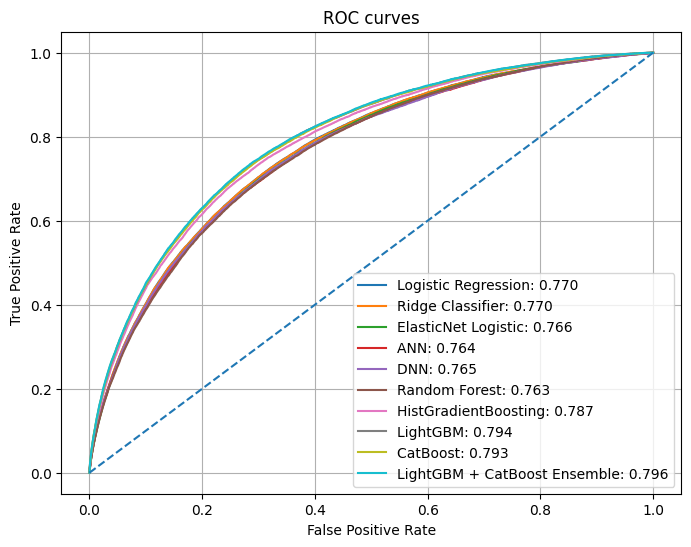

In [15]:
plt.figure(figsize=(8, 6))

for name, oof in oof_predictions.items():
    fpr, tpr, _ = roc_curve(y, oof)
    auc_value = roc_auc_score(y, oof)
    plt.plot(fpr, tpr, label=f"{name}: {auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.grid(True)
plt.show()

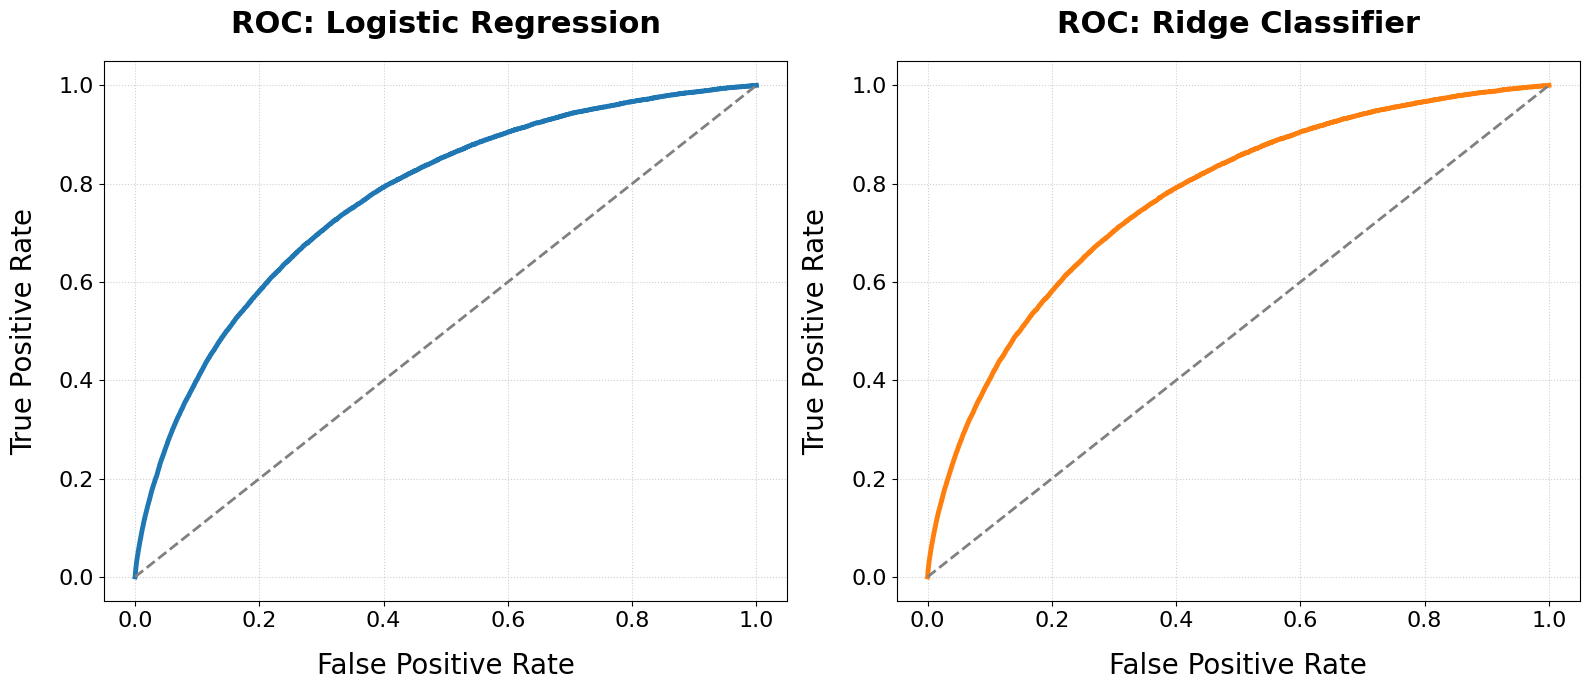

In [ ]:
import matplotlib.pyplot as plt

# Залишаємо базовий розмір, але робимо підписи величезними
plt.figure(figsize=(8, 6))

for name, oof in oof_predictions.items():
    fpr, tpr, _ = roc_curve(y, oof)
    # Тільки назва, лінія товстіша, щоб не губилася на екрані
    plt.plot(fpr, tpr, label=name, linewidth=3)  

# Діагональна лінія
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=2)

# ВЕЛИКІ підписи осей із відступами (labelpad)
plt.xlabel("False Positive Rate", fontsize=18, labelpad=15)
plt.ylabel("True Positive Rate", fontsize=18, labelpad=15)
plt.title("ROC Curves", fontsize=22, fontweight="bold", pad=20)

# ВЕЛИКІ числа на самих осях (0.0, 0.2, 0.4...)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Великий шрифт для легенди
plt.legend(fontsize=14, loc="lower right", framealpha=0.9)

plt.grid(True, linestyle=":", alpha=0.6)

# Ця команда автоматично підгонить відступи, щоб великі написи не вилізли за краї картини
plt.tight_layout()

plt.show()

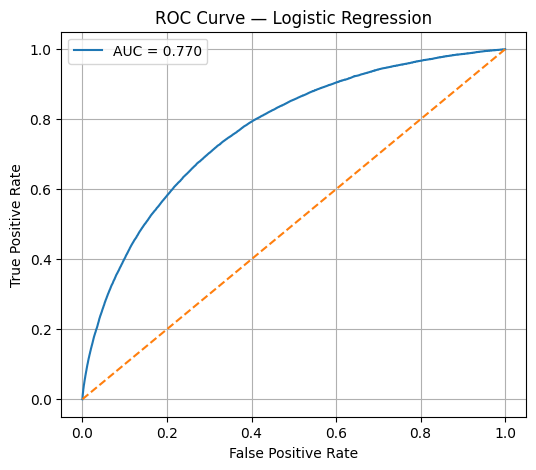

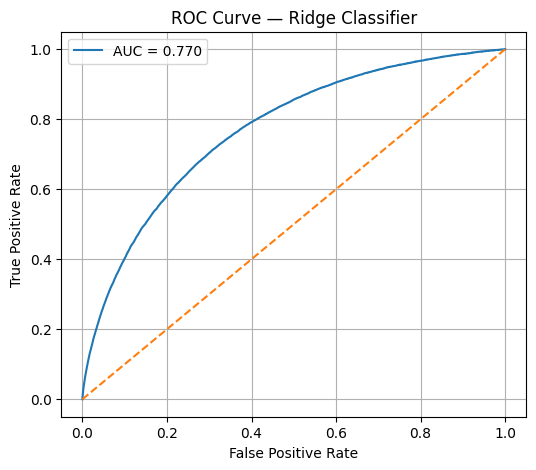

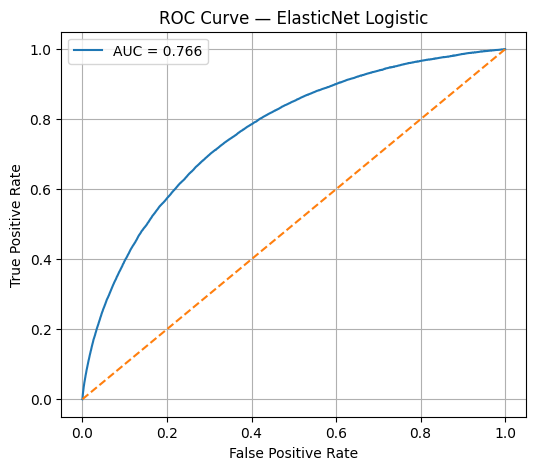

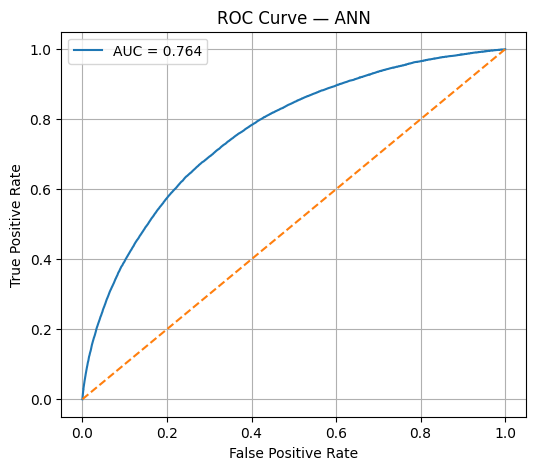

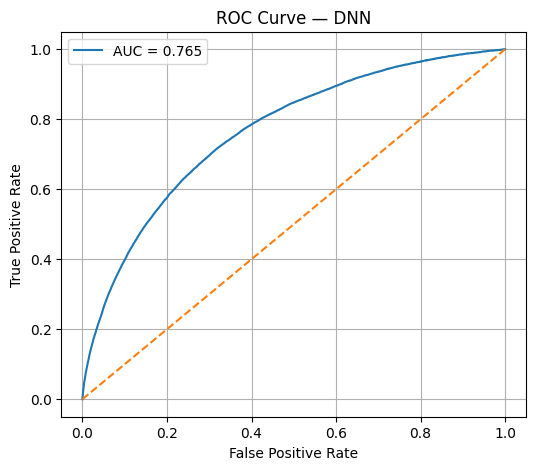

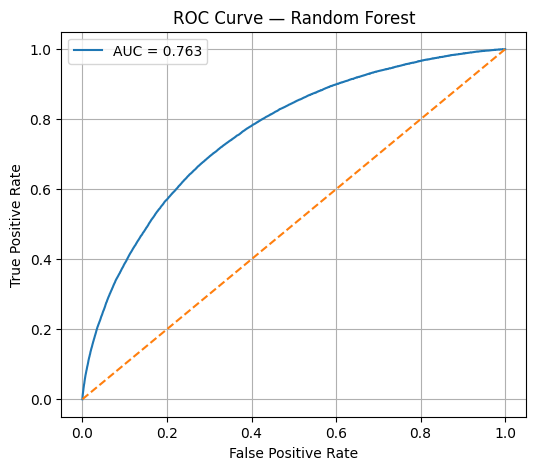

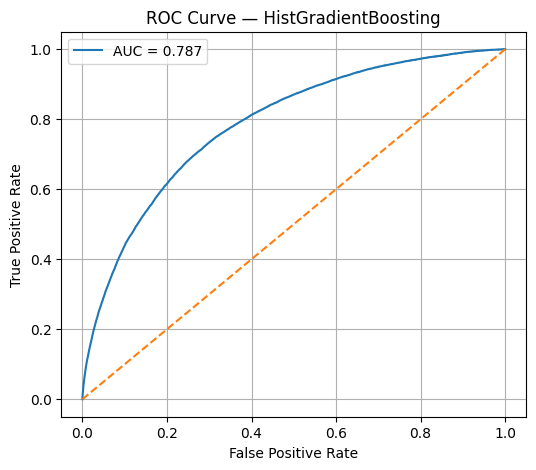

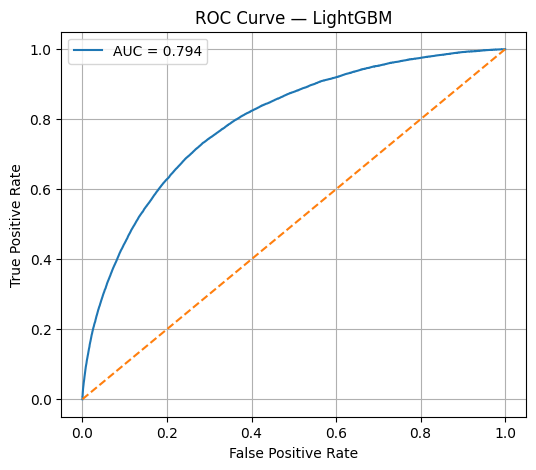

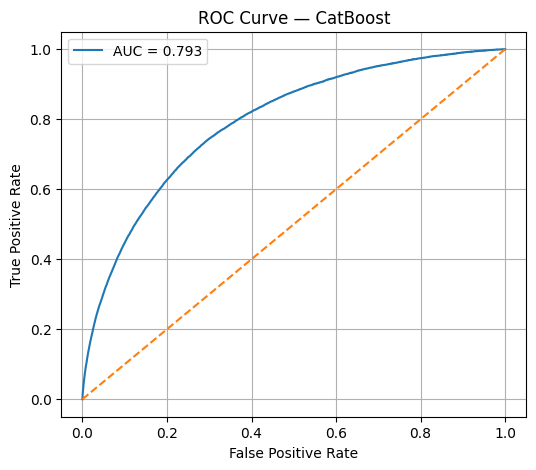

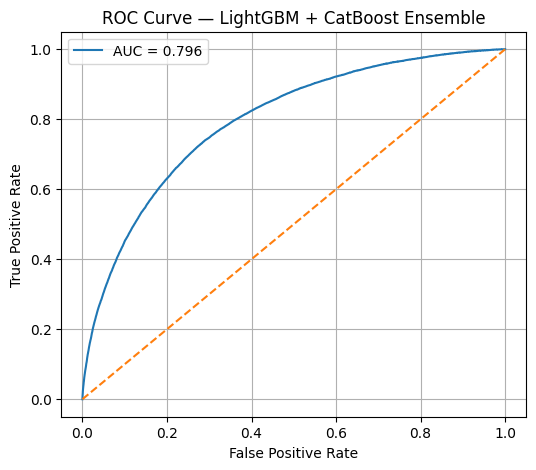

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

for name, oof in oof_predictions.items():
    fpr, tpr, _ = roc_curve(y, oof)
    auc_value = roc_auc_score(y, oof)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend()
    plt.grid(True)

    plt.show()

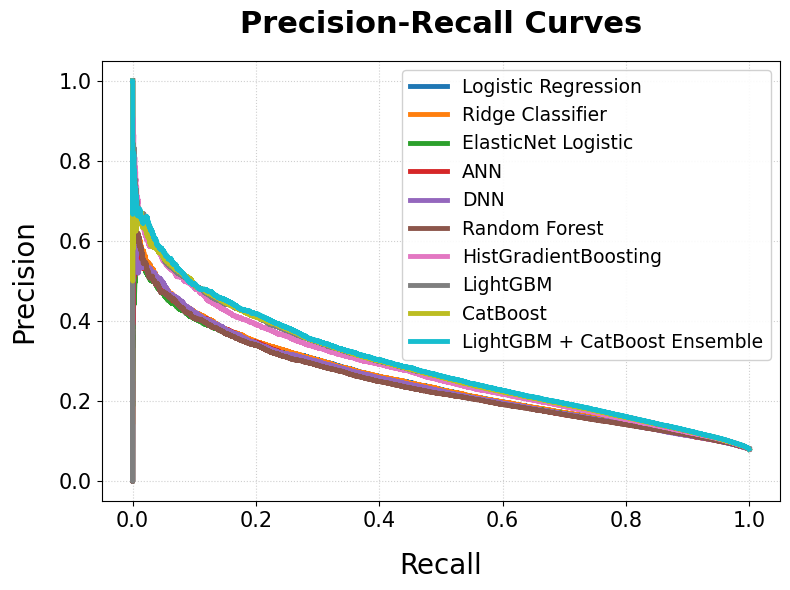

In [21]:
import matplotlib.pyplot as plt

# Компактний розмір фігури для ефекту великих шрифтів при зменшенні
plt.figure(figsize=(8, 6))

for name, oof in oof_predictions.items():
    precision, recall, _ = precision_recall_curve(y, oof)
    # Жирні лінії для презентації, чисті назви без цифр
    plt.plot(recall, precision, label=name, linewidth=3.5)

# Гіпертрофовано великі підписи осей та заголовка з відступами
plt.xlabel("Recall", fontsize=20, labelpad=15)
plt.ylabel("Precision", fontsize=20, labelpad=15)
plt.title("Precision-Recall Curves", fontsize=22, fontweight="bold", pad=20)

# Великі числа на самих осях (0.0, 0.2, 0.4...)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Перенесено у ВЕРХНІЙ ПРАВИЙ кут ("upper right") та збільшено шрифт
plt.legend(fontsize=13.5, loc="upper right", framealpha=0.9)

# Легка, ненав'язлива сітка
plt.grid(True, linestyle=":", alpha=0.6)

# Автоматичне підгоняння полів, щоб великі написи не обрізалися
plt.tight_layout()

plt.show()

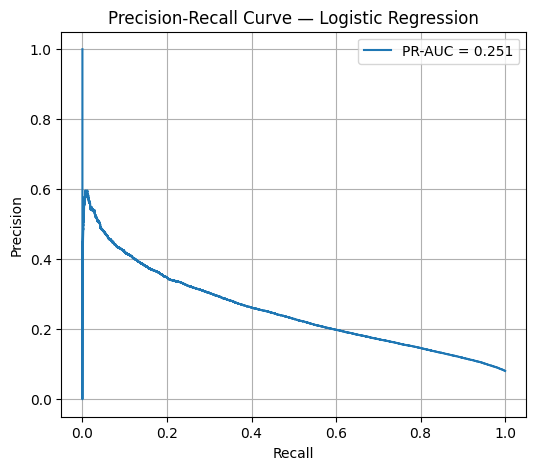

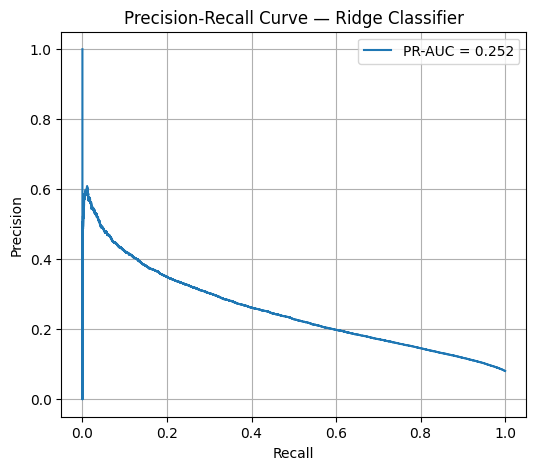

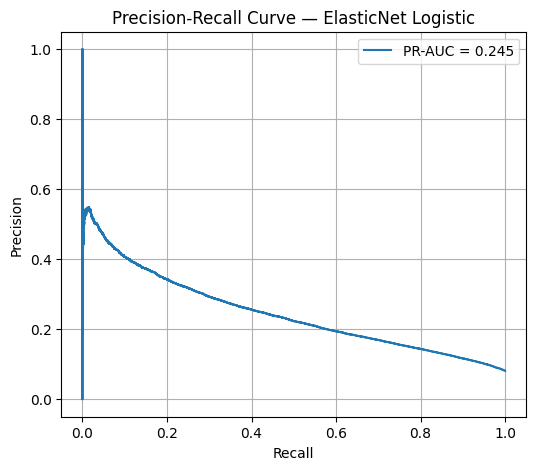

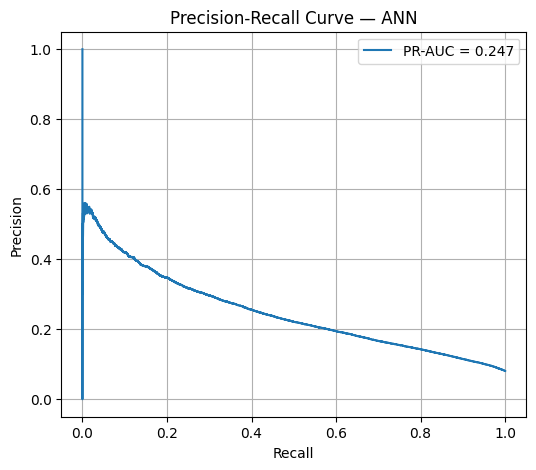

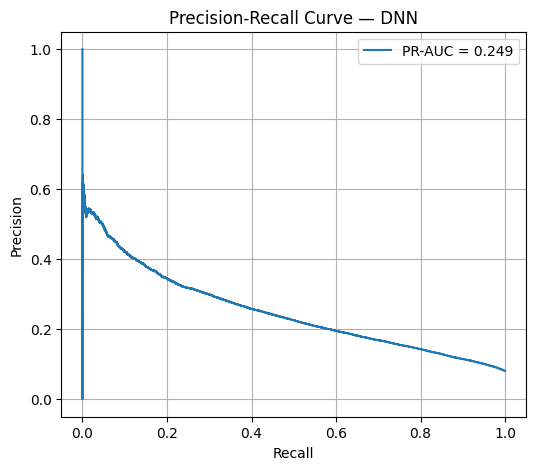

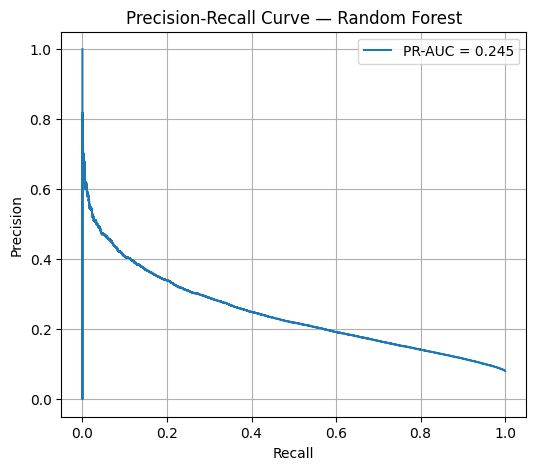

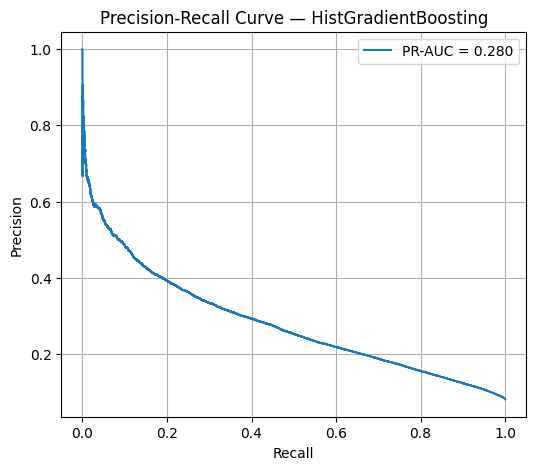

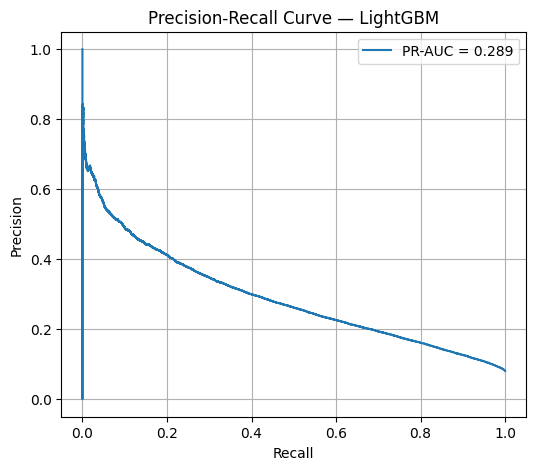

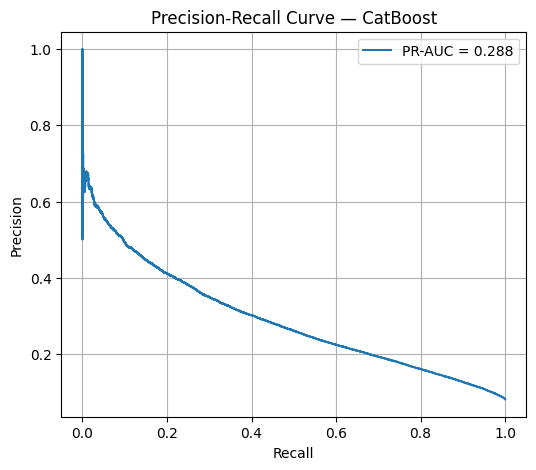

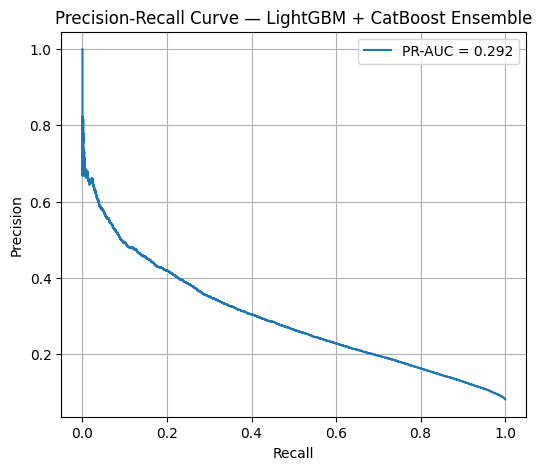

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

for name, oof in oof_predictions.items():
    precision, recall, _ = precision_recall_curve(y, oof)
    pr_value = average_precision_score(y, oof)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_value:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {name}")
    plt.legend()
    plt.grid(True)

    plt.show()

# Частина 6. Аналіз порогу класифікації

Поріг `0.5` не завжди є оптимальним для незбалансованої задачі.  
Тому додатково можна підібрати поріг, який максимізує F1-score для кожної моделі.

Цей блок не змінює навчання моделей, а лише аналізує, як змінюються precision, recall та F1 при іншому порозі.

In [17]:
def find_best_threshold_f1(y_true, scores, thresholds=np.arange(0.05, 0.96, 0.01)):
    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

threshold_rows = []

for name, oof in oof_predictions.items():
    best_t, best_f1 = find_best_threshold_f1(y, oof)
    pred = (oof >= best_t).astype(int)

    threshold_rows.append({
        "model": name,
        "best_threshold_by_F1": best_t,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, oof),
        "PR-AUC": average_precision_score(y, oof)
    })

threshold_results = (
    pd.DataFrame(threshold_rows)
    .sort_values(["F1", "PR-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(threshold_results)

,model,best_threshold_by_F1,precision,recall,F1,ROC-AUC,PR-AUC
0,LightGBM + CatBoost Ensemble,0.16,0.283466,0.451923,0.348400,0.795528,0.291797
1,LightGBM,0.17,0.291737,0.423686,0.345544,0.794223,0.289104
2,CatBoost,0.16,0.280508,0.449547,0.345457,0.793144,0.288011
3,HistGradientBoosting,0.16,0.275823,0.447372,0.341251,0.786964,0.280332
4,Logistic Regression,0.67,0.248741,0.443787,0.318797,0.770204,0.251494
5,Ridge Classifier,0.57,0.248102,0.443585,0.318220,0.770072,0.252213
6,DNN,0.17,0.246873,0.434844,0.314943,0.765033,0.248842
7,ElasticNet Logistic,0.68,0.248559,0.423726,0.313322,0.766051,0.245198
8,ANN,0.16,0.247694,0.420705,0.311808,0.764127,0.246692
9,Random Forest,0.56,0.241827,0.423726,0.307920,0.763389,0.244921


In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

best_roc = -1
best_pr = -1
best_weights = None

results = []

# дрібніший крок, ніж 0.05
for w_lgb in np.arange(0.00, 1.001, 0.001):
    w_cat = 1 - w_lgb
    
    oof_ensemble_temp = w_lgb * oof_lgb + w_cat * oof_cat
    
    roc = roc_auc_score(y, oof_ensemble_temp)
    pr = average_precision_score(y, oof_ensemble_temp)
    
    results.append({
        "w_lgb": w_lgb,
        "w_cat": w_cat,
        "roc_auc": roc,
        "pr_auc": pr
    })
    
    if roc > best_roc:
        best_roc = roc
        best_pr = pr
        best_weights = (w_lgb, w_cat)

weights_df = pd.DataFrame(results)

w_lgb, w_cat = best_weights
oof_ensemble = w_lgb * oof_lgb + w_cat * oof_cat

print("BEST ENSEMBLE WEIGHTS BY ROC-AUC")
print("=" * 50)
print(f"LightGBM weight: {w_lgb:.3f}")
print(f"CatBoost weight: {w_cat:.3f}")
print(f"ROC-AUC: {best_roc:.4f}")
print(f"PR-AUC:  {best_pr:.4f}")

display(weights_df.sort_values("roc_auc", ascending=False).head(10))

BEST ENSEMBLE WEIGHTS BY ROC-AUC
LightGBM weight: 0.578
CatBoost weight: 0.422
ROC-AUC: 0.7955
PR-AUC:  0.2918


,w_lgb,w_cat,roc_auc,pr_auc
578,0.578,0.422,0.795532,0.291810
576,0.576,0.424,0.795532,0.291811
579,0.579,0.421,0.795532,0.291810
577,0.577,0.423,0.795532,0.291811
575,0.575,0.425,0.795532,0.291813
574,0.574,0.426,0.795532,0.291813
580,0.580,0.420,0.795532,0.291811
581,0.581,0.419,0.795532,0.291809
573,0.573,0.427,0.795532,0.291814
582,0.582,0.418,0.795532,0.291810


# Частина 7. Фінальне навчання та збереження моделей

Після порівняння моделей фінальні LightGBM і CatBoost можна навчити на всьому train-наборі та зберегти для подальшого використання.

У цьому блоці зберігаються:

- фінальна LightGBM-модель;
- фінальна CatBoost-модель;
- ваги ансамблю.

In [22]:
import joblib

final_lgb = lgb.LGBMClassifier(
    n_estimators=40000,
    learning_rate=0.015,
    num_leaves=96,
    min_child_samples=80,
    subsample=0.75,
    subsample_freq=1,
    colsample_bytree=0.75,
    reg_lambda=4.0,
    reg_alpha=1.0,
    objective="binary",
    n_jobs=-1,
    random_state=42
)

final_lgb.fit(X, y)

final_cat = CatBoostClassifier(
    iterations=12000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

final_cat.fit(X, y, verbose=False)

joblib.dump(final_lgb, "lightgbm_model.pkl")
final_cat.save_model("catboost_model.cbm")

weights = {
    "lightgbm_weight": float(w_lgb),
    "catboost_weight": float(w_cat)
}

with open("ensemble_weights.json", "w") as f:
    json.dump(weights, f, indent=4)

print("Saved files:")
print("lightgbm_models.pkl")
print("catboost_models.cbm")
print("ensemble_weightss.json")

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,290595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38131
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 201
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,080729 -> initscore=-2,432486
[LightGBM] [Info] Start training from score -2,432486
Saved files:
lightgbm_models.pkl
catboost_models.cbm
ensemble_weightss.json


In [26]:
[name for name in globals().keys() if "cat" in name.lower()]

['classification_report',
 'CatBoostClassifier',
 'evaluate_catboost',
 'oof_cat',
 'cat_models',
 'w_cat',
 'final_cat']

In [ ]:
import os
import pickle
import json

SAVE_DIR = r"c:\programas\diploma\data\notebooks\saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# LightGBM
with open(os.path.join(SAVE_DIR, "lightgbm_models.pkl"), "wb") as f:
    pickle.dump(lgb_models, f)

# CatBoost final model
final_cat.save_model(os.path.join(SAVE_DIR, "catboost_model.cbm"))

# Якщо хочеш зберегти ще й CatBoost-моделі по фолдах
with open(os.path.join(SAVE_DIR, "catboost_models.pkl"), "wb") as f:
    pickle.dump(cat_models, f)

# Ensemble weights
weights = {
    "lightgbm": w_lgb,
    "catboost": w_cat
}

with open(os.path.join(SAVE_DIR, "ensemble_weights.json"), "w", encoding="utf-8") as f:
    json.dump(weights, f, indent=4)

print("Saved to:", SAVE_DIR)


Saved to: c:\programas\diploma\data\notebooks\saved_models
['catboost_model.cbm', 'catboost_models.pkl', 'ensemble_weights.json', 'lightgbm_models.pkl']


## Функція прогнозування ансамблем

Ця функція повертає фінальну ймовірність позитивного класу як зважене середнє прогнозів LightGBM та CatBoost.

In [29]:
def predict_ensemble(X_new):
    p_lgb = final_lgb.predict_proba(X_new)[:, 1]
    p_cat = final_cat.predict_proba(X_new)[:, 1]
    return w_lgb * p_lgb + w_cat * p_cat

# Висновок

Експеримент побудовано послідовно: спочатку перевірено лінійні baseline-моделі, потім нейронні мережі, після цього деревні ансамблі та бустинги.

Accuracy не використовується як основний критерій, оскільки в задачі з дисбалансом класів вона може бути неінформативною. Основний акцент зроблено на ROC-AUC, PR-AUC, precision, recall та F1-score.

Фінальна таблиця дозволяє обґрунтовано порівняти всі підходи за однаковими метриками та вибрати найкращу модель або ансамбль.